In [1]:
# imports
import pandas as pd
import numpy as np
import scipy as sp

import matplotlib.pyplot as plt
import seaborn as sns

from typing import Callable, Optional, List, Self
from numpy.typing import NDArray

from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.linear_model import RANSACRegressor

In [2]:
from kernel_regression_utils import KernelRegressor
from kernel_regression_utils import lKernelType, lH

In [3]:
# defining of features matrix
features_df = pd.read_csv('data/features_with_pb.csv')
features_df = features_df.loc[:, 'CID':]
mX = features_df.loc[:, 'f1_mass_PC1':].to_numpy()
print(mX.shape)

(312, 55)


In [4]:
data_df = pd.read_csv('data/waka_dragon_merged.csv')
data_df.head()

,Unnamed: 0.1,Unnamed: 0,CID,CAS,Name,Imax,Ci,Di_x,intensity_class,MW,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,12,12,179,513-86-0,acetoin,49.69,0.90,0.76,1,88.12,...,54.205,92.70,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.000,0.0
1,40,40,240,100-52-7,benzaldehyde,62.02,1.23,0.69,1,106.13,...,62.810,104.63,0.919,-2.89,-3.00,-3.00,1.0,34.0,0.000,0.0
2,42,42,244,100-51-6,benzyl alcohol,30.28,1.49,0.33,0,108.15,...,65.737,107.27,0.866,-2.74,-2.83,-2.82,1.0,34.0,0.000,0.0
3,89,89,323,91-64-5,coumarin,26.79,0.68,0.77,0,146.15,...,75.670,133.02,0.984,-3.32,-3.47,-3.49,3.0,56.0,0.000,0.0
4,90,90,326,122-03-2,cumin aldehyde,49.53,1.29,0.47,1,148.22,...,91.587,156.53,0.898,-3.70,-3.91,-3.95,1.0,50.0,0.033,0.0


In [5]:
# defining of target matrix
vY = data_df['Imax'].astype(float).values
print(vY.shape)

(312,)


In [6]:
numComb = len(lKernelType) * len(lH)
dData = {
    'Kernel Type': [],
    'h' : [],
    'R2': [0.0] * numComb
} # creation of dictionary

for ii, kernelType in enumerate(lKernelType):
    for jj, paramH in enumerate(lH):
        dData['Kernel Type'].append(kernelType)
        dData['h'].append(paramH)

dfModelScore = pd.DataFrame(data=dData)
dfModelScore

,Kernel Type,h,R2
0,Cosine,4.000000,0.0
1,Cosine,4.040404,0.0
2,Cosine,4.080808,0.0
3,Cosine,4.121212,0.0
4,Cosine,4.161616,0.0
...,...,...,...
395,Uniform,7.838384,0.0
396,Uniform,7.878788,0.0
397,Uniform,7.919192,0.0
398,Uniform,7.959596,0.0


In [7]:
for ii in range(numComb):
    kernelType = dfModelScore.loc[ii, 'Kernel Type']
    paramH = dfModelScore.loc[ii, 'h']

    print(f'Processing model {ii + 1:03d} out of {numComb} with `Kernel Type` = {kernelType} and `h` = {paramH}.')

    oKerReg = KernelRegressor(kernelType = kernelType, paramH = paramH)
    
    vYPred = cross_val_predict(oKerReg, mX, vY, cv = KFold(n_splits = mX.shape[0]))

    scoreR2 = r2_score(vY, vYPred)
    dfModelScore.loc[ii, 'R2'] = scoreR2
    print(f'Finished processing model {ii + 1:03d} with `R2 = {scoreR2}.')


Processing model 001 out of 400 with `Kernel Type` = Cosine and `h` = 4.0.
Finished processing model 001 with `R2 = -5.922140488503593.
Processing model 002 out of 400 with `Kernel Type` = Cosine and `h` = 4.040404040404041.
Finished processing model 002 with `R2 = -5.922140488503593.
Processing model 003 out of 400 with `Kernel Type` = Cosine and `h` = 4.08080808080808.
Finished processing model 003 with `R2 = -5.922140488503593.
Processing model 004 out of 400 with `Kernel Type` = Cosine and `h` = 4.121212121212121.
Finished processing model 004 with `R2 = -5.922140488503593.
Processing model 005 out of 400 with `Kernel Type` = Cosine and `h` = 4.161616161616162.
Finished processing model 005 with `R2 = -5.922140488503593.
Processing model 006 out of 400 with `Kernel Type` = Cosine and `h` = 4.202020202020202.
Finished processing model 006 with `R2 = -5.922140488503593.
Processing model 007 out of 400 with `Kernel Type` = Cosine and `h` = 4.242424242424242.
Finished processing model 

In [8]:
dfModelScore.sort_values(by='R2', ascending=False).head(10)

,Kernel Type,h,R2
149,Gaussian,5.979798,0.381771
148,Gaussian,5.939394,0.381503
147,Gaussian,5.898990,0.381209
146,Gaussian,5.858586,0.380888
145,Gaussian,5.818182,0.380540
144,Gaussian,5.777778,0.380164
143,Gaussian,5.737374,0.379759
142,Gaussian,5.696970,0.379324
141,Gaussian,5.656566,0.372609
140,Gaussian,5.616162,0.372113


In [10]:
# Trial to implement RANSAC
best_mae = np.inf
best_ratio = None

for ratio in np.arange(0.35, 1.00, 0.05):

    ransac = RANSACRegressor(
        estimator=KernelRegressor(
            kernelType='Gaussian',
            paramH=5.98
        ),
        min_samples=ratio,
        max_trials=1000,
        random_state=42
    )

    ransac.fit(mX, vY)

    inlier_mask = ransac.inlier_mask_

    mX_clean = mX[inlier_mask]
    vY_clean = vY[inlier_mask]

    vYPred_clean = cross_val_predict(KernelRegressor(kernelType='Gaussian', paramH=5.98), mX_clean, vY_clean, cv=KFold(n_splits=len(vY_clean), shuffle=True, random_state=42))
    mae = mean_absolute_error(vY_clean, vYPred_clean)
    r2 = r2_score(vY_clean, vYPred_clean)
    

    print(f"ratio={ratio:.2f}, MAE={mae:.3f}")
    print(f"ratio={ratio:.2f}, R2={r2:.3f}")

    if mae < best_mae:
        best_mae = mae
        best_ratio = ratio
        best_inlier_mask = inlier_mask.copy()

print(f"\nBest ratio={best_ratio:.2f}")
print(f"Best MAE={best_mae:.3f}")

ratio=0.35, MAE=6.668
ratio=0.35, R2=0.539
ratio=0.40, MAE=6.452
ratio=0.40, R2=0.625
ratio=0.45, MAE=6.594
ratio=0.45, R2=0.545
ratio=0.50, MAE=7.019
ratio=0.50, R2=0.516
ratio=0.55, MAE=7.132
ratio=0.55, R2=0.545
ratio=0.60, MAE=7.244
ratio=0.60, R2=0.450
ratio=0.65, MAE=7.169
ratio=0.65, R2=0.488
ratio=0.70, MAE=7.352
ratio=0.70, R2=0.475
ratio=0.75, MAE=7.387
ratio=0.75, R2=0.499
ratio=0.80, MAE=7.295
ratio=0.80, R2=0.450
ratio=0.85, MAE=7.462
ratio=0.85, R2=0.468
ratio=0.90, MAE=7.307
ratio=0.90, R2=0.490
ratio=0.95, MAE=7.413
ratio=0.95, R2=0.468

Best ratio=0.40
Best MAE=6.452


In [21]:
inlier_mask.sum()

np.int64(261)

In [11]:
mX_clean = mX[best_inlier_mask]
vY_claen = vY[best_inlier_mask]

oBestKernelReg = KernelRegressor(kernelType='Gaussian', paramH=5.98).fit(mX_clean, vY_claen)
vY_pred = oBestKernelReg.predict(mX)


In [12]:
r2 = r2_score(vY, vY_pred)
print(f"R2: {r2:.2f}")

mae = mean_absolute_error(vY, vY_pred)
print(f"MAE: {mae:.2f}")

R2: 0.55
MAE: 6.73


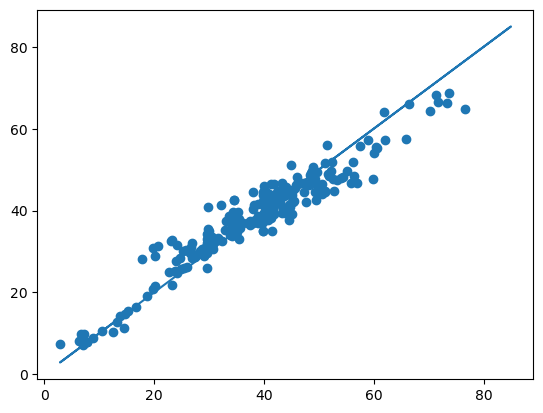

In [16]:
fig, ax = plt.subplots()

ax.scatter(vY[best_inlier_mask], vY_pred[best_inlier_mask])
ax.plot(vY, vY)

plt.show()



In [26]:
# now i want to check cross validation result on best estomator:

vY_pred_cv = cross_val_predict(KernelRegressor(kernelType='Gaussian', paramH=5.98), mX_clean, vY_claen, cv = KFold(n_splits=len(vY_claen), shuffle=True, random_state=42))

r2 = r2_score(vY[best_inlier_mask], vY_pred_cv)
print(f"R2: {r2:.2f}")

mae = mean_absolute_error(vY[best_inlier_mask], vY_pred_cv)
print(f"MAE: {mae:.2f}")

R2: 0.63
MAE: 6.45


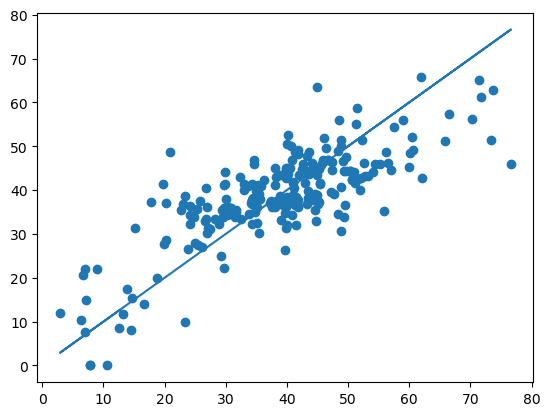

In [18]:
fig, ax = plt.subplots()

ax.scatter(vY[best_inlier_mask], vY_pred_cv)
ax.plot(vY[best_inlier_mask], vY[best_inlier_mask])

plt.show()


In [19]:
len(vY_pred_cv)

238